In [1]:
print("hi")

hi


In [35]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [36]:
class no_of_digits_state(TypedDict):
    number:int
    no_of_digits:int
    qutient:int
    

In [37]:
graph=StateGraph(no_of_digits_state)

In [38]:
def display(state:no_of_digits_state):
    state['no_of_digits']=0
    state['qutient']=state['number']
    return state


def check_qutient(state:no_of_digits_state):
    print(f'qutient is {state["qutient"]}')


def check_condition(state:no_of_digits_state)->Literal['division_by_10','summary']:
    if state['qutient']>0:
        return 'division_by_10'
    else:
        return 'summary'

def division_by_10(state:no_of_digits_state):
    state['no_of_digits']+=1
    state['qutient']=state['qutient']//10
    return state

def summary(state:no_of_digits_state):
    print(f'Number of digits are {state["no_of_digits"]} present in number {state["number"]}')
    return state



In [39]:
# defining the nodes
graph.add_node("display",display)
graph.add_node("check_qutient",check_qutient)
graph.add_node("division_by_10",division_by_10)
graph.add_node('summary',summary)

graph.add_edge(START,'display')
graph.add_edge('display','check_qutient')
graph.add_conditional_edges('check_qutient',check_condition)
graph.add_edge('division_by_10','check_qutient')
graph.add_edge('summary',END)

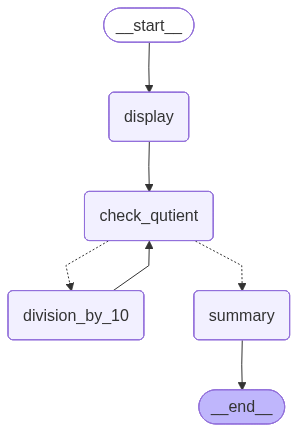

In [40]:
workflow=graph.compile()
workflow

In [41]:
initial_state={'number':32987}
output=workflow.invoke(initial_state)
output

qutient is 32987
qutient is 3298
qutient is 329
qutient is 32
qutient is 3
qutient is 0
Number of digits are 5 present in number 32987


{'number': 32987, 'no_of_digits': 5, 'qutient': 0}

In [43]:
state=no_of_digits_state(workflow.invoke({'number':1234567890}))
state


qutient is 1234567890
qutient is 123456789
qutient is 12345678
qutient is 1234567
qutient is 123456
qutient is 12345
qutient is 1234
qutient is 123
qutient is 12
qutient is 1
qutient is 0
Number of digits are 10 present in number 1234567890


{'number': 1234567890, 'no_of_digits': 10, 'qutient': 0}

In [44]:
output=workflow.invoke({'number':1234567890})
output

qutient is 1234567890
qutient is 123456789
qutient is 12345678
qutient is 1234567
qutient is 123456
qutient is 12345
qutient is 1234
qutient is 123
qutient is 12
qutient is 1
qutient is 0
Number of digits are 10 present in number 1234567890


{'number': 1234567890, 'no_of_digits': 10, 'qutient': 0}

In [45]:
initial_state={'number':1234567890}
output=workflow.invoke(initial_state)
output

qutient is 1234567890
qutient is 123456789
qutient is 12345678
qutient is 1234567
qutient is 123456
qutient is 12345
qutient is 1234
qutient is 123
qutient is 12
qutient is 1
qutient is 0
Number of digits are 10 present in number 1234567890


{'number': 1234567890, 'no_of_digits': 10, 'qutient': 0}

In [4]:
32%10

2

In [5]:
32//10


3

In [8]:
3//10

0